In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e1/sample_submission.csv
/kaggle/input/playground-series-s5e1/train.csv
/kaggle/input/playground-series-s5e1/test.csv
/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot_tr.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot_tr.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target_wtFC.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target_wtSC.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot_tr.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl
/kaggle/input/datasets/davibaca/s

In [2]:
!pip install -U optuna
import optuna
print(optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.1.0
    Uninstalling optuna-4.1.0:
      Successfully uninstalled optuna-4.1.0
5.0.0


In [3]:
!pip install -U scikit-learn
import sklearn
print(sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
1.7.2


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [5]:
# Create functions

# Time series features
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df


In [6]:
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
test_df.head()


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


# Data analysis

In [8]:
#Type of variables
train_df.dtypes

id                   int64
date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

Three variables type object, one type date time. Dependent variable type numeric

In [9]:
train_df["country"].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [10]:
train_df.groupby('country')['num_sold'].sum()

country
Canada       28653095.0
Finland      28698872.0
Italy        20797669.0
Kenya          689141.0
Norway       54562305.0
Singapore    33102374.0
Name: num_sold, dtype: float64

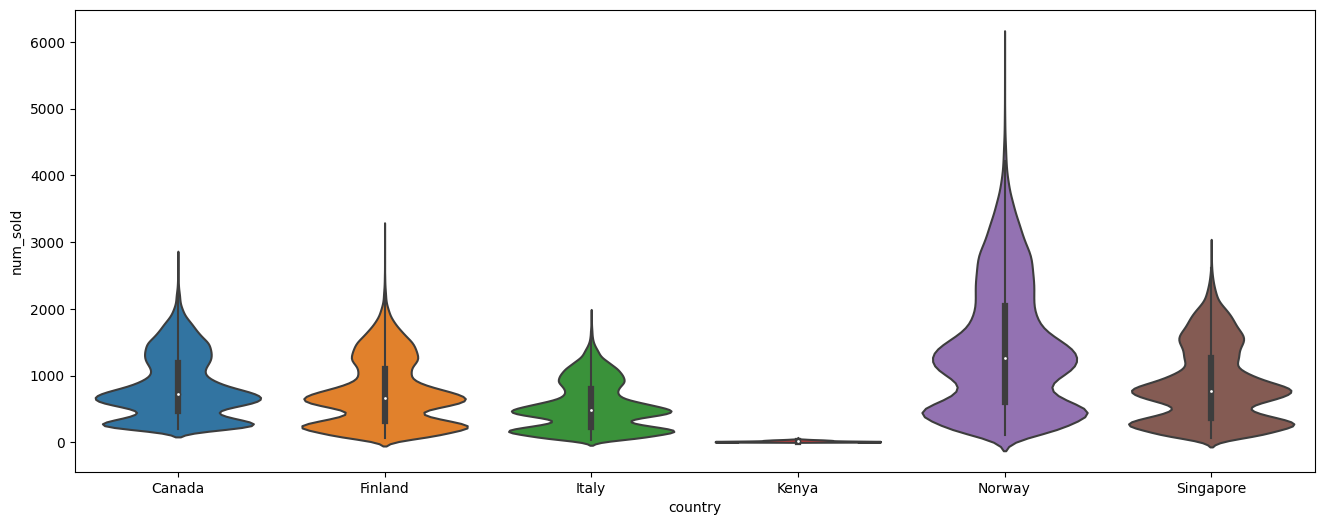

In [11]:
plt.figure(figsize=(16, 6))

sns.violinplot(x='country', y='num_sold', data=train_df, scale='width')

plt.show()

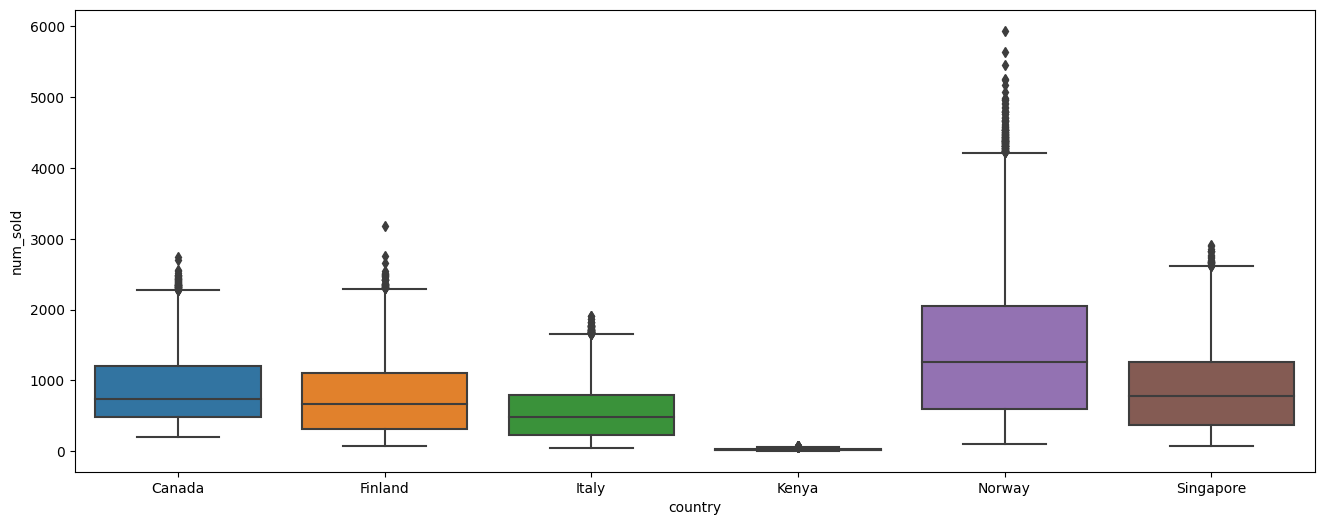

In [12]:
plt.figure(figsize=(16, 6))

sns.boxplot(x='country', y='num_sold', data=train_df)

plt.show()

In [13]:
train_df["store"].value_counts()

store
Discount Stickers       76710
Stickers for Less       76710
Premium Sticker Mart    76710
Name: count, dtype: int64

In [14]:
train_df.groupby('store')['num_sold'].sum()

store
Discount Stickers       30599237.0
Premium Sticker Mart    73703822.0
Stickers for Less       62200397.0
Name: num_sold, dtype: float64

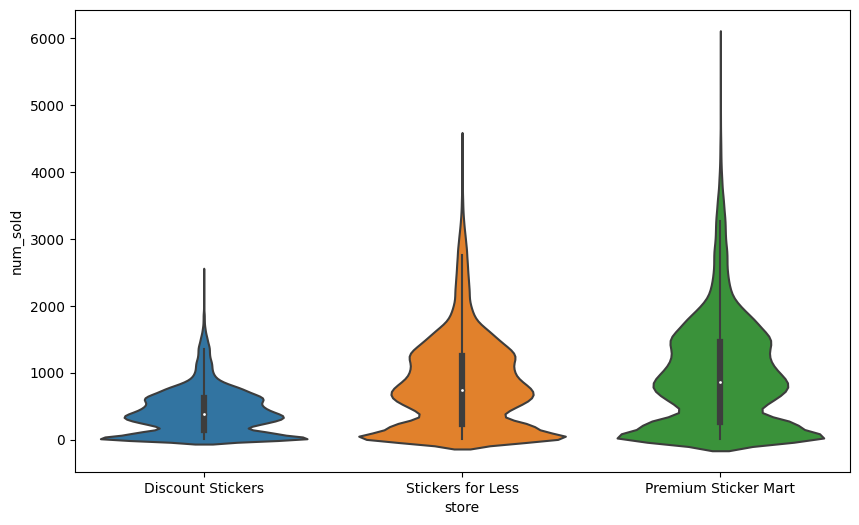

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='store', y='num_sold', data=train_df, scale='width')

plt.show()

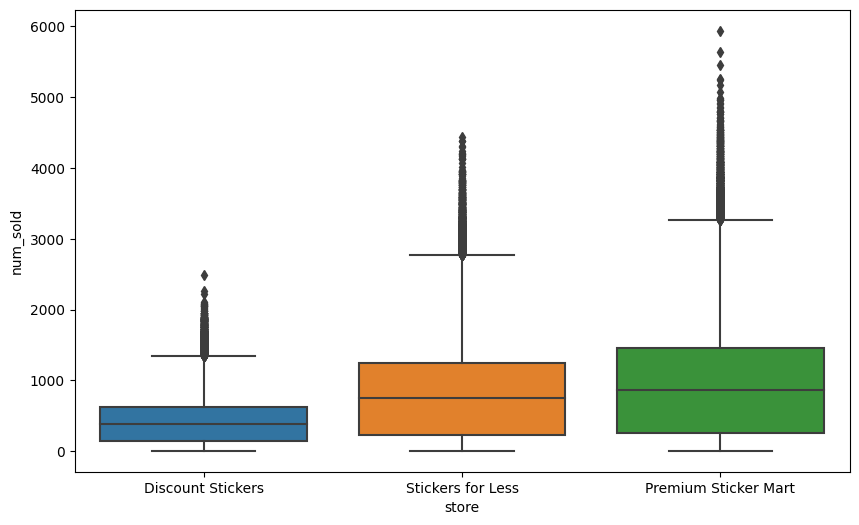

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='store', y='num_sold', data=train_df)

plt.show()

In [17]:
train_df["product"].value_counts()

product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
Name: count, dtype: int64

In [18]:
train_df.groupby('product')['num_sold'].sum()

product
Holographic Goose      7350368.0
Kaggle                56721733.0
Kaggle Tiers          46870306.0
Kerneler              25596840.0
Kerneler Dark Mode    29964209.0
Name: num_sold, dtype: float64

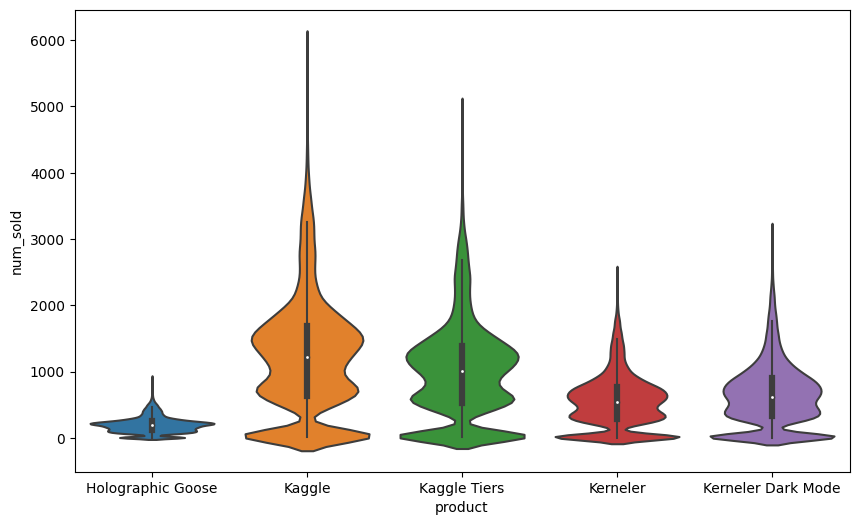

In [19]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='product', y='num_sold', data=train_df, scale='width')

plt.show()

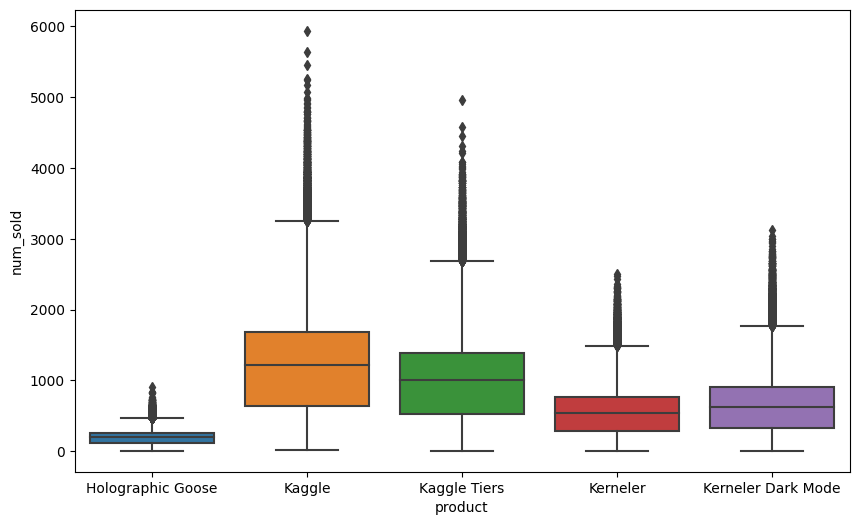

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='product', y='num_sold', data=train_df)

plt.show()

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# NAs

<Axes: xlabel='product', ylabel='country'>

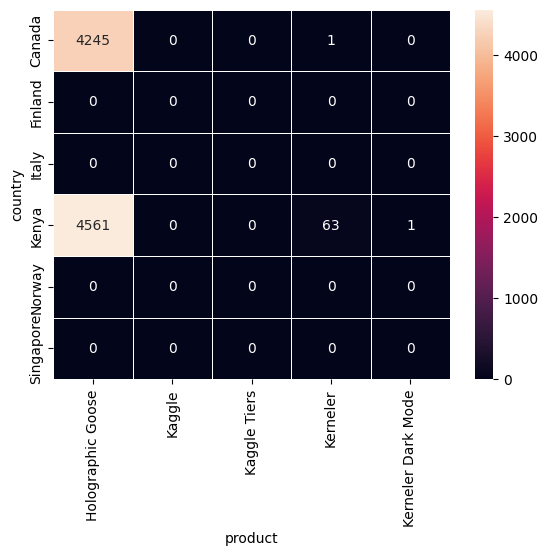

In [21]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='store', ylabel='country'>

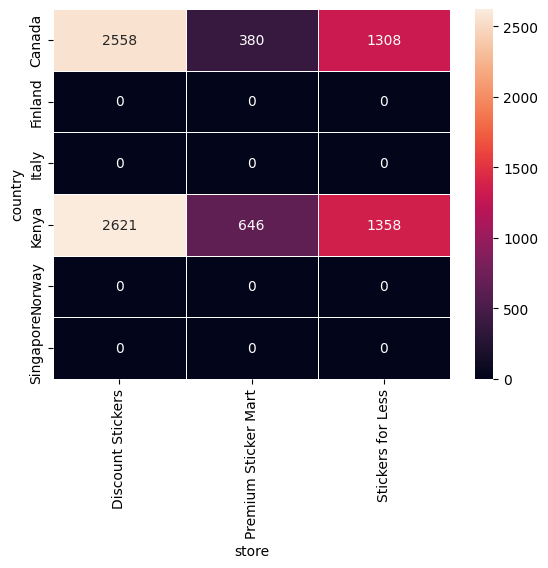

In [22]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['store'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='product', ylabel='store'>

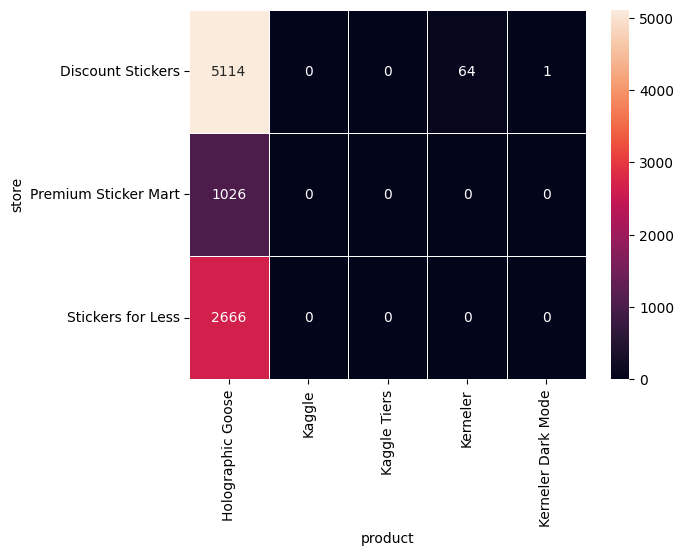

In [23]:
nas_matrix = pd.crosstab(
    index=train_df['store'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


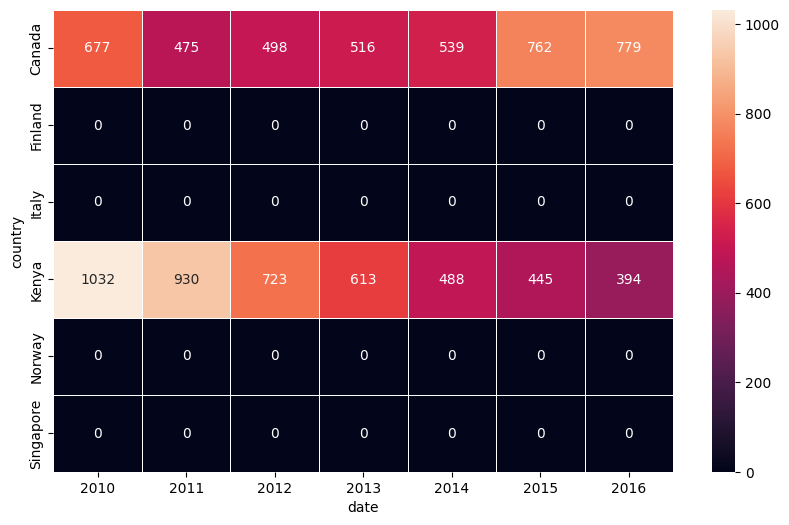

In [24]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.year,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(10, 6))

sns.heatmap(
    nas_matrix,
    annot=True,
    fmt='g',
    linewidths=0.5,
)
plt.show()

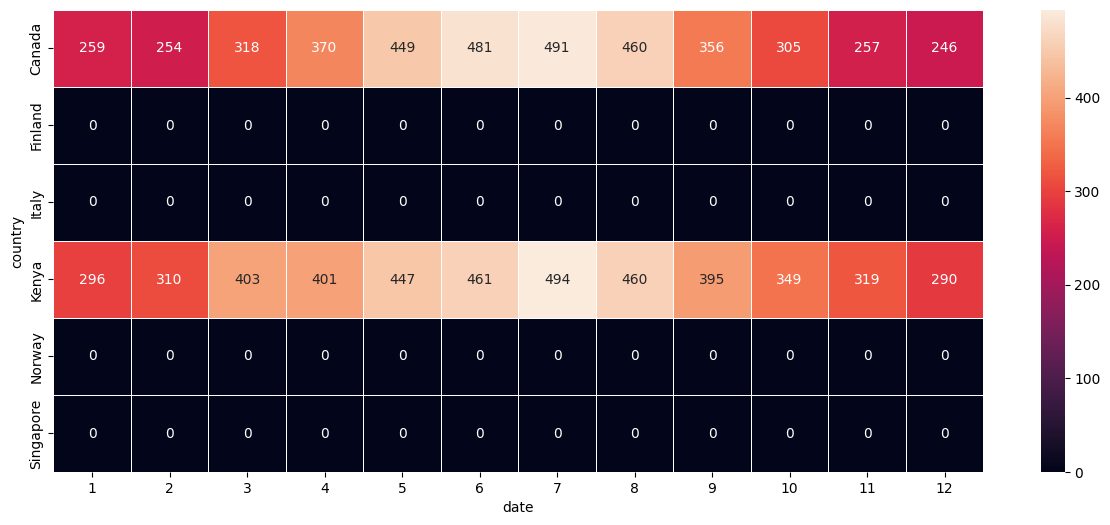

In [25]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.month,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(15, 6))
sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)
plt.show()

It seems that there is a patron in the data loss Canda and Kenya had lost the same product (holographic goose). The store which had lost more data is Discount Stickers followed by Stickers for Less and Premium Sticker Mart. There also seems to be a patron with year, where first years of data get more lost.

We are going to look closer to Canada and Kenya

In [26]:
df_Canada = train_df[train_df['country']=='Canada'].copy()
df_Kenya = train_df[train_df['country']=='Kenya'].copy()

<Axes: xlabel='product', ylabel='store'>

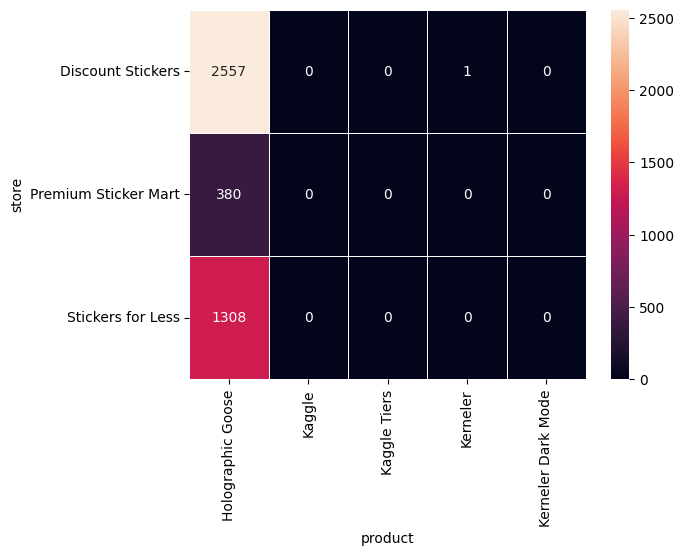

In [27]:
nas_matrix = pd.crosstab(
    index=df_Canada['store'],
    columns=df_Canada['product'],  
    values=df_Canada['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

<Axes: xlabel='product', ylabel='store'>

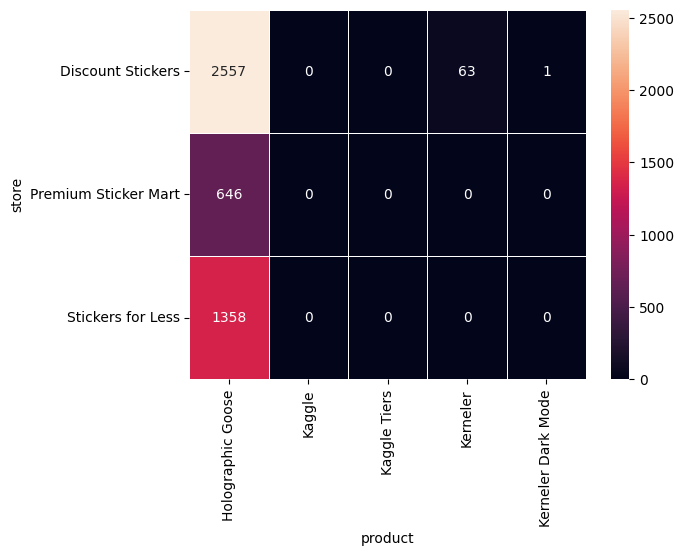

In [28]:
nas_matrix = pd.crosstab(
    index=df_Kenya['store'],
    columns=df_Kenya['product'],  
    values=df_Kenya['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

In [29]:
group_means = train_df.groupby(['product', 'country','store'])['num_sold'].mean().to_dict()
group_means

{('Holographic Goose', 'Canada', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 248.3821773082223,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 228.8166533226581,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 98.00156433320298,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 235.26046147829487,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 198.95580758701604,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 70.84630426280798,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 170.38287055142746,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 144.0183809151349,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 5.941915227629513,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 5.470391993327773,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 186.7258506061791,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart

In [30]:
count_grupo = train_df.groupby(['product', 'country','store'])['num_sold'].count().to_dict()
count_grupo

{('Holographic Goose', 'Canada', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 2177,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 1249,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 1911,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 1199,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Norway', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Singapore', 'Discount Stickers'): 2557,
 ('Holographic 

In [31]:
zero_df = (train_df['num_sold']==0).sum()
zero_df

0

There are two groups with no means. meaning there is no value. Probably the NAs are 0 due to the fact that there is not 0 value. So we are going to imputate with 0

In [32]:
train_df.duplicated().sum()

0

In [33]:
# Solve the NAs problems on X data
train_df_without_na=train_df.fillna(0)

# Outliers

<Axes: ylabel='num_sold'>

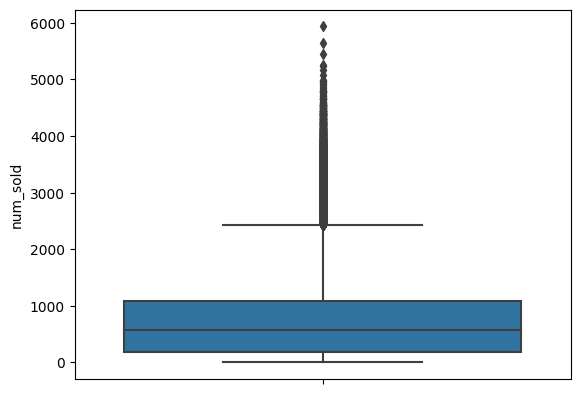

In [34]:
sns.boxplot(data=train_df_without_na, y="num_sold")

# DATA transformation

In [35]:
# See which columns are type categorical and store them
s = (train_df_without_na.dtypes == 'object')
object_cols = list(s[s].index)
print(f"Categorical variables:\n{object_cols}")

Categorical variables:
['country', 'store', 'product']


In [36]:
split_date = '2014-01-02'

data_train = train_df_without_na.copy()
data_train = data_train.sort_values('id')

split_train = data_train[data_train['date'] < split_date]
split_val = data_train[data_train['date'] >= split_date]

In [37]:
from sklearn.model_selection import TimeSeriesSplit

def target_encode_group_oof(
    df, group_cols, target_col,
    n_splits=5, smoothing=10
):
    df = df.sort_values('date').copy()

    tscv = TimeSeriesSplit(n_splits=n_splits)

    encoded = pd.Series(index=df.index, dtype=float)
    global_mean = df[target_col].mean()

    for train_idx, val_idx in tscv.split(df):

        fold_train = df.iloc[train_idx]
        fold_val = df.iloc[val_idx]

        means = fold_train.groupby(group_cols)[target_col].mean()
        counts = fold_train.groupby(group_cols)[target_col].count()

        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)

        val_keys = fold_val[group_cols].apply(tuple, axis=1)

        encoded.loc[fold_val.index] = (val_keys.map(smoothed.to_dict()))

    return encoded.fillna(global_mean)

X_train_tar = split_train.copy()
X_test_tar = test_df.copy() 
X_val_tar = split_val.copy()


global_mean = X_train_tar['num_sold'].mean()

# Interaction encodings
X_train_tar['country_store_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store'], 'num_sold'
)
X_train_tar['store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['store', 'product'], 'num_sold'
)
X_train_tar['country_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'product'], 'num_sold'
)

X_train_tar['country_store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store', 'product'], 'num_sold', smoothing=20 
)
def build_group_encoding_map(df, group_cols, target_col, smoothing, global_mean):
    means = df.groupby(group_cols)[target_col].mean()
    counts = df.groupby(group_cols)[target_col].count()
    return (means * counts + global_mean * smoothing) / (counts + smoothing)

cs_map = build_group_encoding_map(X_train_tar, ['country', 'store'], 'num_sold', 20, global_mean)
sp_map = build_group_encoding_map(X_train_tar, ['store', 'product'], 'num_sold', 20, global_mean)
cp_map = build_group_encoding_map(X_train_tar, ['country', 'product'], 'num_sold', 20, global_mean)
csp_map = build_group_encoding_map(X_train_tar, ['country', 'store', 'product'], 'num_sold', 20, global_mean)

X_test_tar['country_store_encoded'] = X_test_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_test_tar['store_product_encoded'] = X_test_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_test_tar['country_product_encoded'] = X_test_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_test_tar['country_store_product_encoded'] = X_test_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)

X_val_tar['country_store_encoded'] = X_val_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_val_tar['store_product_encoded'] = X_val_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_val_tar['country_product_encoded'] = X_val_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_val_tar['country_store_product_encoded'] = X_val_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)


In [38]:
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[('target_enc', TargetEncoder(smooth='auto', target_type='continuous'), object_cols)], remainder='drop')
X_train_tar_v2 = preprocessor.fit_transform(X_train_tar.drop('num_sold', axis=1), X_train_tar['num_sold'])
X_test_tar_v2 = preprocessor.transform(X_test_tar)
X_val_tar_v2 = preprocessor.transform(X_val_tar)


feature_names = preprocessor.get_feature_names_out()

X_train_tar_v2 = pd.DataFrame(
    X_train_tar_v2, 
    columns=feature_names,
    index=X_train_tar.index
).astype(float)

X_test_tar_v2 = pd.DataFrame(
    X_test_tar_v2, 
    columns=feature_names,
    index=X_test_tar.index
).astype(float)

X_val_tar_v2 = pd.DataFrame(
    X_val_tar_v2, 
    columns=feature_names,
    index=X_val_tar.index
).astype(float)

X_train_tar_v2 = X_train_tar_v2.apply(pd.to_numeric)
X_test_tar_v2 = X_test_tar_v2.apply(pd.to_numeric)
X_val_tar_v2 = X_val_tar_v2.apply(pd.to_numeric)

X_train_tarenc = pd.concat([X_train_tar, X_train_tar_v2, split_train.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)
X_test_tarenc = pd.concat([X_test_tar, X_test_tar_v2, test_df.drop(['id', 'date', 'country', 'store', 'product'], axis=1)], axis=1)

X_val_tarenc = pd.concat([X_val_tar, X_val_tar_v2, split_val.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)

print("Train DataFrame shape:", X_train_tarenc.shape)
print("Test DataFrame shape:", X_test_tarenc.shape)
print("Validation DataFrame shape:", X_val_tarenc.shape)


Train DataFrame shape: (131580, 13)
Test DataFrame shape: (98550, 12)
Validation DataFrame shape: (98550, 13)


In [39]:
#Create a new column to differentiate the three dataFrame and join them
X_train_tarenc['df'] = 'train'
X_test_tarenc['df'] = 'test'
X_val_tarenc['df'] = 'val'
df_merged = pd.concat([X_train_tarenc, X_test_tarenc,X_val_tarenc], ignore_index=True)
df_merged = df_merged.reset_index(drop=True)

#add a time-step feature 
df_merged = df_merged.sort_values(['country', 'store', 'product', 'date'])
df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() 

#Use the function create_features to get time features
df_merged = create_features(df_merged)

df_merged.shape

(328680, 22)

In [40]:
# see new dataframe columns
print(f"Dataframe columns:\n{df_merged.columns}")

Dataframe columns:
Index(['id', 'date', 'country', 'store', 'product', 'num_sold',
       'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')


In [41]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['df']=='train'].num_sold
y_val = df_merged[df_merged['df']=='val'].num_sold
df_x = df_merged.drop('num_sold', axis=1).copy()

In [42]:
#Transforming the categorical variables from the test and training data into numerical
import sklearn
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, feature_name_combiner='concat')
OH_array  = OH_encoder.fit_transform(df_x[object_cols])
OH_cols_df = pd.DataFrame(OH_array, columns=OH_encoder.get_feature_names_out(object_cols), index=df_x.index
)
OH_cols_df

,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
230126,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
230127,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
230128,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
#Merge the categorical variables with the other variables
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)

OH_x_df.columns

Index(['id', 'date', 'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'country_Canada', 'country_Finland',
       'country_Italy', 'country_Kenya', 'country_Norway', 'country_Singapore',
       'store_Discount Stickers', 'store_Premium Sticker Mart',
       'store_Stickers for Less', 'product_Holographic Goose',
       'product_Kaggle', 'product_Kaggle Tiers', 'product_Kerneler',
       'product_Kerneler Dark Mode'],
      dtype='object')

In [44]:
#Make sure there isn't no NAs
print(f"NAs num_sold: {y_train.isnull().sum()} \n\n NAs varialbes: \n{OH_x_df.isnull().sum()}")


NAs num_sold: 0 

 NAs varialbes: 
id                               0
date                             0
country_store_encoded            0
store_product_encoded            0
country_product_encoded          0
country_store_product_encoded    0
target_enc__country              0
target_enc__store                0
target_enc__product              0
df                               0
Time                             0
dayofweek                        0
quarter                          0
month                            0
year                             0
dayofyear                        0
dayofmonth                       0
weekofyear                       0
country_Canada                   0
country_Finland                  0
country_Italy                    0
country_Kenya                    0
country_Norway                   0
country_Singapore                0
store_Discount Stickers          0
store_Premium Sticker Mart       0
store_Stickers for Less          0
product_Holographic 

In [45]:
#Separate the test data and training data
X_train = OH_x_df[OH_x_df['df']=='train'].drop(['id', 'df', 'date'], axis=1).copy()
X_test = OH_x_df[OH_x_df['df']=='test'].drop(['id', 'df', 'date'], axis=1).copy()
X_val = OH_x_df[OH_x_df['df']=='val'].drop(['id', 'df', 'date'], axis=1).copy()

In [46]:
import joblib
import json
import optuna
import optuna.visualization as vis
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, root_mean_squared_error,
    root_mean_squared_log_error
)
from sklearn.model_selection import cross_val_score, learning_curve, TimeSeriesSplit
from optuna.pruners import MedianPruner
from functools import partial

# Kaggle directory for saving files
Output_directory= '/kaggle/working/'

# Save dataframes
X_train.to_parquet(f'{Output_directory}X_train.parquet')
X_test.to_parquet(f'{Output_directory}X_test.parquet')
X_val.to_parquet(f'{Output_directory}X_val.parquet')
y_train.to_frame(name='sales').to_parquet(f'{Output_directory}y_train.parquet')
y_val.to_frame(name='sales').to_parquet(f'{Output_directory}y_val.parquet')

# Time-based validation: respects chronological order, never validates on data prior to that fold's train set
tscv = TimeSeriesSplit(n_splits=5)
    
# Pruner
pruner = MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=2,
    interval_steps=1,
    n_min_trials=8,
)

# Early stopping: stops the whole study if the best value hasn't improved in the last `patience` trials
def early_stopping(study, trial, patience=30, start_trial_number=0):
    trials_since_start = trial.number - start_trial_number
    if trials_since_start < patience:
        return

    best_trial_number = study.best_trial.number
    if best_trial_number < start_trial_number:
        trials_without_improvement = trials_since_start
    else:
        trials_without_improvement = trial.number - best_trial_number

    if trials_without_improvement >= patience:
        print(f"No improvement in the last {patience} trials. Stopping study.")
        study.stop()
#Sampler with seed for every model
sampler= optuna.samplers.TPESampler(seed=42)

#####################################################################
# METRICS
#####################################################################

def cross_val(model, X_train, y_train, name=""):
    scores = -cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    print(f"--- {name}: Cross-validation (5 folds) ---")
    print(f"RMSE por fold: {np.round(scores, 4)}")
    print(f"Media: {scores.mean():.4f} | Std: {scores.std():.4f} | CV%: {scores.std()/scores.mean()*100:.2f}%")
    return {'cv_mean': scores.mean(), 'cv_std': scores.std()}
def cross_val_xgb(params, X, y, tscv):
    scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

        X_tr = X.iloc[train_idx]
        X_va = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_va = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            early_stopping_rounds=30
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        scores.append(rmse)

        print(f"Fold {fold + 1}: {rmse:.4f}")

    print(f"CV mean: {np.mean(scores):.4f}")
    print(f"CV std: {np.std(scores):.4f}")

    return np.array(scores)
def plot_learning_curve(model, X_train, y_train, name=""):

    model_lc = xgb.XGBRegressor(
        **model.get_params()
    )

    # Remove early stopping
    model_lc.set_params(early_stopping_rounds=None)

    train_sizes, train_scores, val_scores = learning_curve(
        model_lc,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_rmse, label="Train RMSE")
    plt.plot(train_sizes, val_rmse, label="Validation RMSE")
    plt.xlabel("Training samples")
    plt.ylabel("RMSE")
    plt.title(f"Learning Curve - {name}")
    plt.legend()
    plt.show()
def evaluate_additional_metrics(y_true, y_pred, name=""):
    errors = y_true - y_pred
    error_pct = np.abs(errors / y_true) * 100

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100
    try:
        rmsle = root_mean_squared_log_error(y_true, y_pred)
    except ValueError:
        rmsle = None  # fails if there are negative predictions

    print(f"--- {name}: Additional metrics ---")
    print(f"MAE: {mae:.4f} | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", end="")
    print(f" | RMSLE: {rmsle:.4f}" if rmsle is not None else " | RMSLE: N/A (negative predictions)")
    print(f"Bias (mean error): {errors.mean():.4f}")
    print(f"Prediction std: {y_pred.std():.4f} | Real std: {y_true.std():.4f}")
    for tol in [10, 15, 20]:
        successes = (error_pct <= tol).mean() * 100
        print(f"Within ±{tol}%: {successes:.2f}%")
        
def evaluate_gap(y_train, pred_train, y_val, pred_val, name=""):
    rmse_train = root_mean_squared_error(y_train, pred_train)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    gap = rmse_val - rmse_train
    gap_pct = gap / rmse_train * 100

    print(f"--- {name}: Train vs Val ---")
    print(f"RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")
    print(f"Gap: {gap:.4f} ({gap_pct:.2f}%)")

    return {'rmse_train': rmse_train, 'rmse_val': rmse_val, 'gap_pct': gap_pct}


In [47]:
#Remove variables with high correlation
X_train = X_train.drop(['Time', 'quarter', 'dayofmonth','month', 'weekofyear'], axis=1).copy()

X_val = X_val.drop(['Time', 'quarter', 'dayofmonth','month', 'weekofyear'], axis=1).copy()

X_test = X_test.drop(['Time', 'quarter', 'dayofmonth','month', 'weekofyear'], axis=1).copy()

In [48]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 500),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.80),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.50, 0.80),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb.best_params}")

#saves the study
joblib.dump(study_xgb, f'{Output_directory}study_xgb.pkl')

#Load study 
#study_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb.pkl')

[I 2026-09-19 22:45:28,339] A new study created in memory with name: no-name-c4a5935d-8af7-42d0-b3d5-50d56eb15fe5
[I 2026-09-19 22:45:44,837] Trial 0 finished with value: 131.57082951276882 and parameters: {'n_estimators': 687, 'learning_rate': 0.0568376349572445, 'max_depth': 4, 'min_child_weight': 319, 'gamma': 1.4322493718230251, 'subsample': 0.6311989040672406, 'colsample_bytree': 0.5145209030420499, 'colsample_bylevel': 0.7598528437324805, 'reg_alpha': 1.5930522616241019, 'reg_lambda': 93.76542954502837}. Best is trial 0 with value: 131.57082951276882.
[I 2026-09-19 22:45:58,786] Trial 1 finished with value: 128.22738296328953 and parameters: {'n_estimators': 510, 'learning_rate': 0.058048981109277205, 'max_depth': 4, 'min_child_weight': 145, 'gamma': 1.5199348301309807, 'subsample': 0.6366809019706867, 'colsample_bytree': 0.5760605607398844, 'colsample_bylevel': 0.6574269294896714, 'reg_alpha': 0.7309539835912913, 'reg_lambda': 47.93819615223106}. Best is trial 1 with value: 128.

XGBoost best parameters: {'n_estimators': 545, 'learning_rate': 0.04908227522716691, 'max_depth': 4, 'min_child_weight': 58, 'gamma': 1.3470038023813178, 'subsample': 0.6501606743251286, 'colsample_bytree': 0.720198991001901, 'colsample_bylevel': 0.6772536935219124, 'reg_alpha': 0.4580939705916898, 'reg_lambda': 45.845144546451806}


['/kaggle/working/study_xgb.pkl']

In [49]:
print(f"Trials executed: {len(study_xgb.trials)}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

Trials executed: 200
Best trial: 190
Best RMSE: 124.4819
Best parameters: {'n_estimators': 545, 'learning_rate': 0.04908227522716691, 'max_depth': 4, 'min_child_weight': 58, 'gamma': 1.3470038023813178, 'subsample': 0.6501606743251286, 'colsample_bytree': 0.720198991001901, 'colsample_bylevel': 0.6772536935219124, 'reg_alpha': 0.4580939705916898, 'reg_lambda': 45.845144546451806}


In [50]:
df_trials_xgb = study_xgb.trials_dataframe()
print(df_trials_xgb[['number', 'value','state']].tail(15))

     number       value     state
185     185  131.969172    PRUNED
186     186  125.411108  COMPLETE
187     187  131.806151    PRUNED
188     188  126.317852  COMPLETE
189     189  125.298056  COMPLETE
190     190  124.481908  COMPLETE
191     191  125.982843  COMPLETE
192     192  131.817650    PRUNED
193     193  125.419177  COMPLETE
194     194  125.415995  COMPLETE
195     195  124.861475  COMPLETE
196     196  125.518099  COMPLETE
197     197  125.257578  COMPLETE
198     198  126.308434  COMPLETE
199     199  125.366270  COMPLETE


In [51]:
vis.plot_optimization_history(study_xgb).show()
vis.plot_param_importances(study_xgb).show()

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



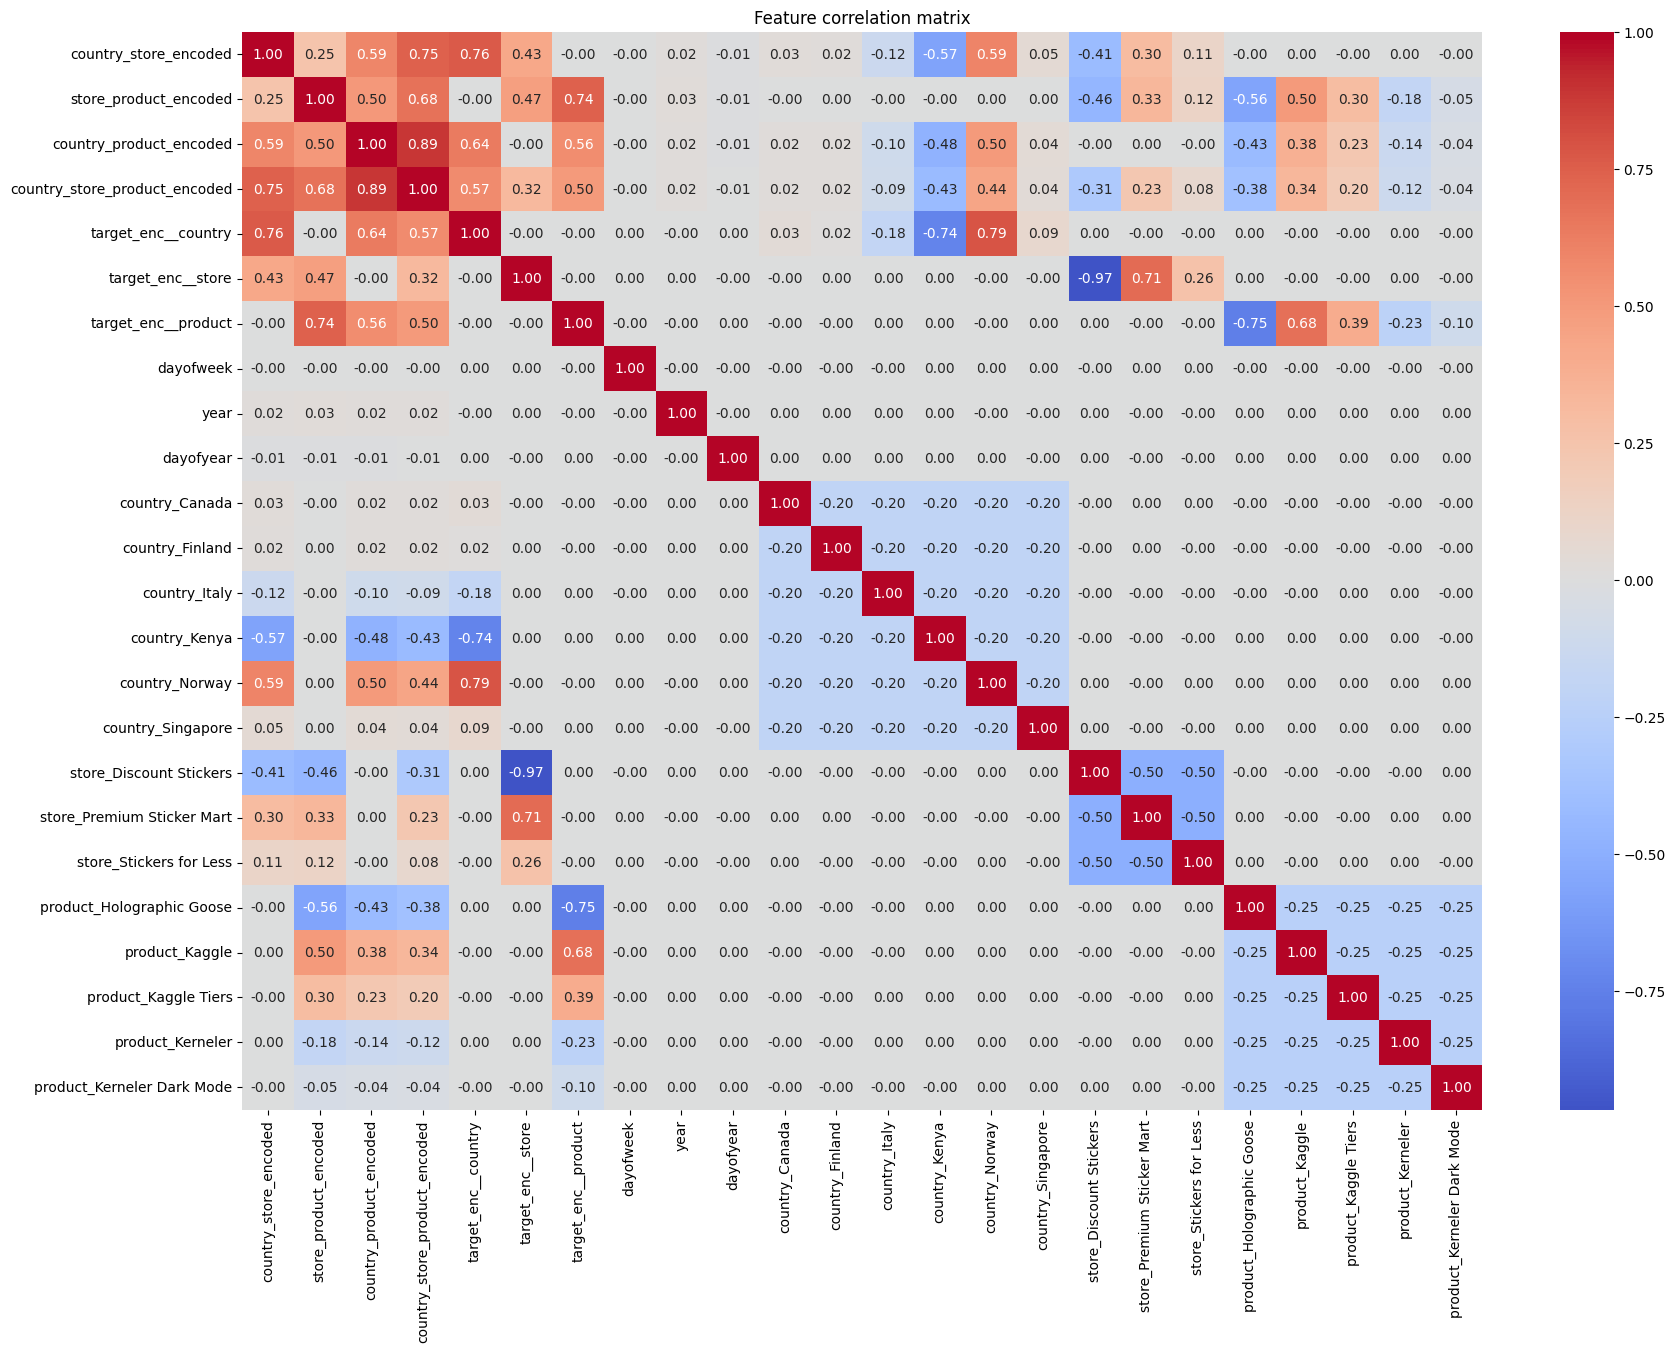

In [52]:
# Autocorrelation matrix
corr_matrix = X_train.corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,  fmt='.2f', annot=True)
plt.title('Feature correlation matrix')
plt.show()


In [53]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train) * 0.8)

df_train = X_train.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, early_stopping_rounds=30)
model_xgb.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb, f'{Output_directory}model_xgb.pkl')

#Load study 
#model_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

['/kaggle/working/model_xgb.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 94.6455 | RMSE val: 187.3233
Gap: 92.6779 (97.92%)
--- XGBoost: Additional metrics ---
MAE: 103.8877 | MAPE: 1112924183346153600.00% | R²: 0.9148 | RMSLE: N/A (negative predictions)
Bias (mean error): -64.9932
Prediction std: 726.5782 | Real std: 641.8150
Within ±10%: 40.15%
Within ±15%: 53.30%
Within ±20%: 62.25%
Fold 1: 159.8938
Fold 2: 113.7959
Fold 3: 137.8931
Fold 4: 112.1115
Fold 5: 98.7153
CV mean: 124.4819
CV std: 21.7485


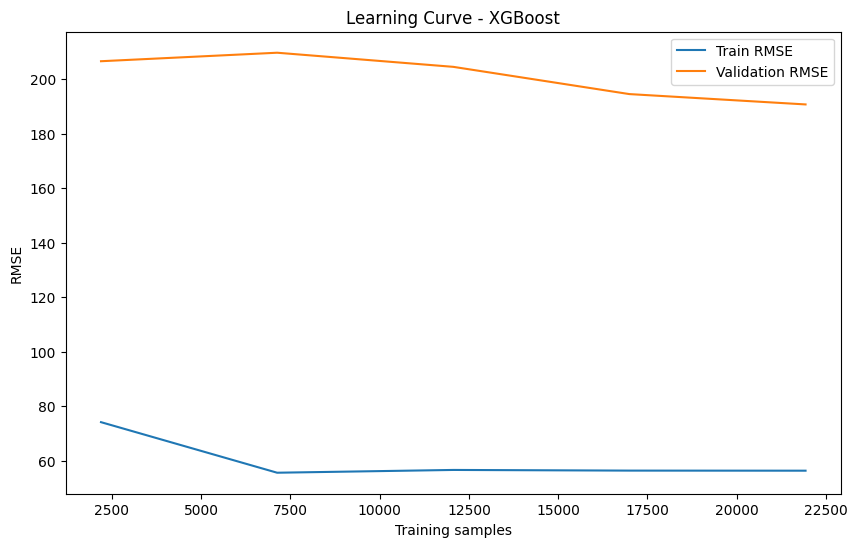

In [54]:
pred_train_xgb = model_xgb.predict(X_train)
pred_val_xgb = model_xgb.predict(X_val)
gap_xgb = evaluate_gap(y_train, pred_train_xgb, y_val, pred_val_xgb, "XGBoost")
addmet_xgb_trget = evaluate_additional_metrics(y_val, pred_val_xgb, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb.best_params,
    X_train,
    y_train,
    tscv)
plot_learning_curve(model_xgb, X_train, y_train, "XGBoost")


In [55]:
results = pd.DataFrame({
    'date': data_train.loc[data_train['date'] >= split_date, 'date'].values,
    'y_true': y_val.values,
    'y_pred': pred_val_xgb
})

results['year'] = results['date'].dt.year

rmse_by_year = (
    results.groupby('year')
    .apply(lambda x: root_mean_squared_error(x['y_true'], x['y_pred']))
)

print(rmse_by_year)

year
2014     97.564174
2015    199.865931
2016    235.962881
dtype: float64


<ipython-input-55-38f075c88f8d>:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [56]:
print(
    results.groupby('year')['y_true']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

            mean  median         std  min     max  count
year                                                    
2014  747.661844   600.0  706.087613  0.0  5643.0  32760
2015  666.152390   526.0  619.874054  0.0  3996.0  32850
2016  653.438767   528.0  590.076990  0.0  3466.0  32940


In [57]:
print(
    results.groupby('year')['y_pred']
    .agg(['mean', 'median', 'std', 'min', 'max'])
)

            mean      median         std        min          max
year                                                            
2014  753.453430  608.094482  726.239807 -29.547283  4204.861816
2015  753.809937  608.094482  726.347595 -29.547283  4101.517578
2016  754.707764  608.094482  727.176941 -28.120705  4168.038574


In [58]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_xgb, X_val, y_val, random_state=42, n_repeats=10)
#Load study 
#perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm, f'{Output_directory}permutation_result.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
3   country_store_product_encoded         0.211592    8.016126e-04
6             target_enc__product         0.082702    6.611279e-04
4             target_enc__country         0.065361    7.561378e-04
7                       dayofweek         0.030305    5.151772e-04
5               target_enc__store         0.017749    4.108978e-04
9                       dayofyear         0.012005    1.995216e-04
2         country_product_encoded         0.004310    2.135852e-04
16        store_Discount Stickers         0.004253    2.549841e-04
13                  country_Kenya         0.002182    1.277655e-04
22               product_Kerneler         0.001370    2.136570e-05
23     product_Kerneler Dark Mode         0.000937    1.922741e-05
20                 product_Kaggle         0.000724    1.306981e-04
15              country_Singapore         0.000359    3.983480e-06
19      product_Holographic Goose         0.000334    1.169335

In [59]:
import shap

SAMPLE_SIZE = 5000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

explainer_lgb = shap.TreeExplainer(model_xgb)
shap_values_lgb = explainer_lgb.shap_values(X_train_sample, check_additivity=False)

shap_lgb = pd.DataFrame({
    'feature': X_train_sample.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_lgb['pct'] = shap_lgb['mean_abs_shap'] / shap_lgb['mean_abs_shap'].sum() * 100

print(shap_lgb)

# Flag features below a threshold as candidates for removal
UMBRAL_PCT = 0.5  # adjust as needed

candidates_to_drop = shap_lgb[shap_lgb['pct'] < UMBRAL_PCT]['feature'].tolist()
print(f"\nCandidate features to drop (< {UMBRAL_PCT}% of total importance):")
print(candidates_to_drop)

                          feature  mean_abs_shap        pct
0   country_store_product_encoded     171.541763  19.137087
1             target_enc__product     124.952660  13.939637
2             target_enc__country     105.765541  11.799134
3         country_product_encoded      91.483711  10.205863
4               target_enc__store      65.036011   7.255374
5                       dayofweek      47.308289   5.277682
6           country_store_encoded      41.077511   4.582580
7         store_Discount Stickers      40.680336   4.538271
8                   country_Kenya      34.359737   3.833150
9                  country_Norway      33.310677   3.716117
10      product_Holographic Goose      30.570269   3.410399
11                 product_Kaggle      23.417795   2.612474
12          store_product_encoded      22.656919   2.527591
13                      dayofyear      21.394516   2.386758
14                           year      20.226034   2.256403
15     store_Premium Sticker Mart      1

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

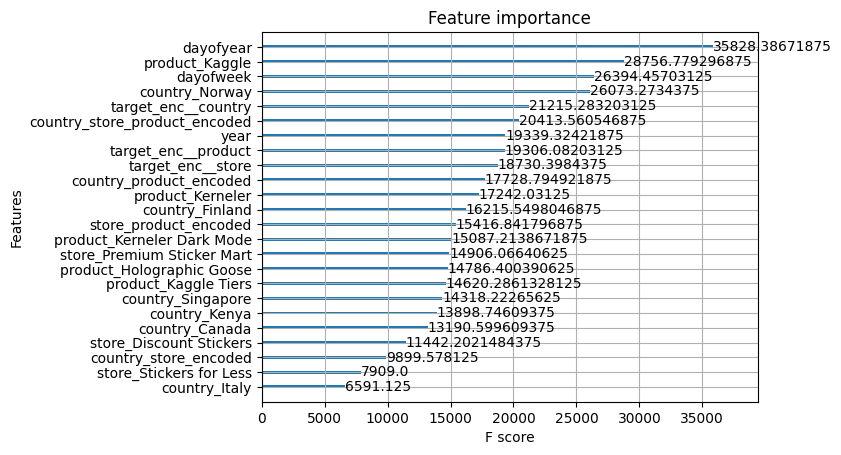

In [60]:
xgb.plot_importance(model_xgb, importance_type='cover')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

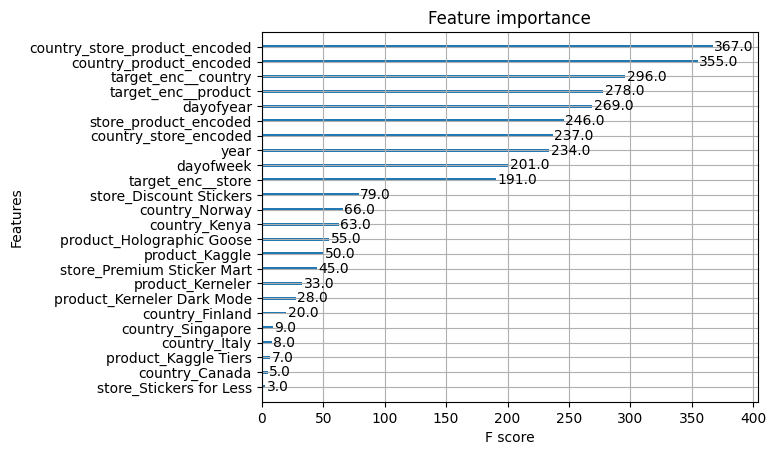

In [61]:
xgb.plot_importance(model_xgb, importance_type='weight')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

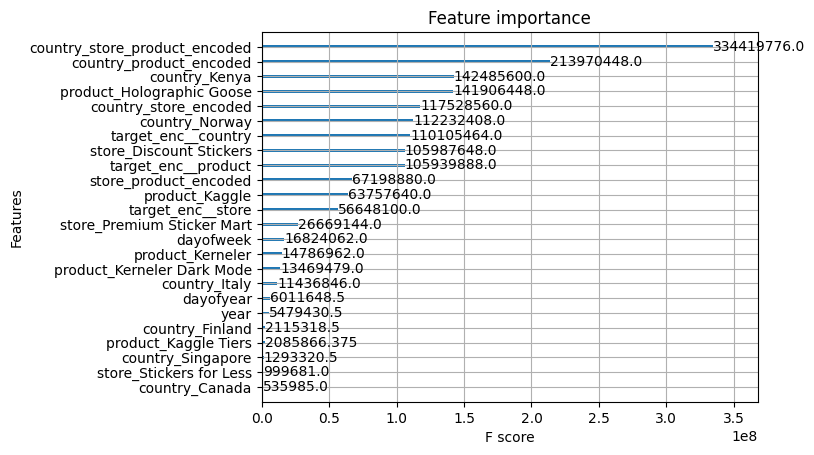

In [62]:
xgb.plot_importance(model_xgb, importance_type='gain')

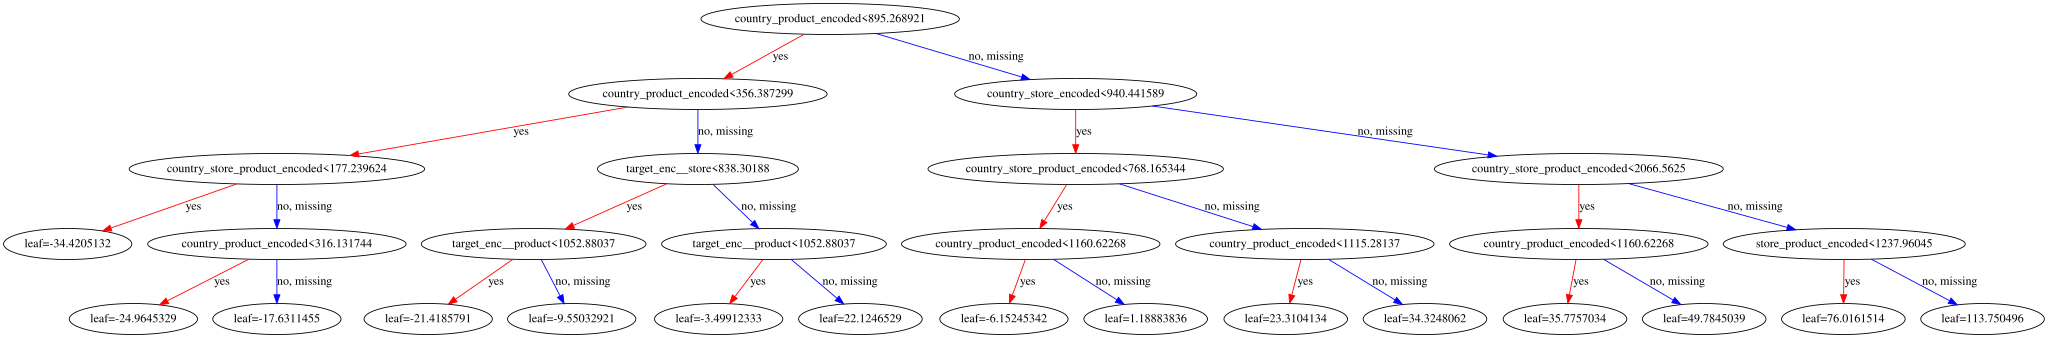

In [63]:
xgb.to_graphviz(model_xgb, num_trees=0)

In [64]:
#Target encoded dataframe
X_train_target = X_train.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target = X_val.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_test_target = X_test.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [65]:
# 1. XGBoost with only target encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 150),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.60, 0.80),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.50, 0.80),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target)):
        X_tr, X_va = X_train_target.iloc[train_idx], X_train_target.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target.best_params}")

# saves the study
joblib.dump(study_xgb_target, f'{Output_directory}study_xgb_target.pkl')

#Load study 
#study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-19 23:32:28,831] A new study created in memory with name: no-name-6827c1b5-4701-408c-a34b-f6808e484ef0
[I 2026-09-19 23:32:36,736] Trial 0 finished with value: 168.37413605149592 and parameters: {'n_estimators': 322, 'learning_rate': 0.04024157125029554, 'max_depth': 2, 'min_child_weight': 101, 'gamma': 8.082886378162032, 'subsample': 0.649858445829775, 'colsample_bytree': 0.6025957307589074, 'colsample_bylevel': 0.7266653415629146, 'reg_alpha': 0.28681134821030074, 'reg_lambda': 33.95688959639594}. Best is trial 0 with value: 168.37413605149592.
[I 2026-09-19 23:32:49,277] Trial 1 finished with value: 142.6783444702062 and parameters: {'n_estimators': 503, 'learning_rate': 0.023875479284914885, 'max_depth': 4, 'min_child_weight': 131, 'gamma': 4.299359454731439, 'subsample': 0.7742921180375436, 'colsample_bytree': 0.7009180192247786, 'colsample_bylevel': 0.5559710176658108, 'reg_alpha': 6.0970252974914345, 'reg_lambda': 71.46695918389604}. Best is trial 1 with value: 142.67

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 797, 'learning_rate': 0.049964002186872844, 'max_depth': 4, 'min_child_weight': 61, 'gamma': 1.8624966344593767, 'subsample': 0.7394871902597776, 'colsample_bytree': 0.7190811273833662, 'colsample_bylevel': 0.7471718357851225, 'reg_alpha': 3.990064450300441, 'reg_lambda': 33.65863446919031}


['/kaggle/working/study_xgb_target.pkl']

In [66]:
print(f"Trials executed: {len(study_xgb_target.trials)}")
print(f"Best trial: {study_xgb_target.best_trial.number}")
print(f"Best RMSE: {study_xgb_target.best_value:.4f}")
print(f"Best parameters: {study_xgb_target.best_params}")

Trials executed: 87
Best trial: 26
Best RMSE: 128.5597
Best parameters: {'n_estimators': 797, 'learning_rate': 0.049964002186872844, 'max_depth': 4, 'min_child_weight': 61, 'gamma': 1.8624966344593767, 'subsample': 0.7394871902597776, 'colsample_bytree': 0.7190811273833662, 'colsample_bylevel': 0.7471718357851225, 'reg_alpha': 3.990064450300441, 'reg_lambda': 33.65863446919031}


In [67]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target) * 0.8)

df_train = X_train_target.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target = xgb.XGBRegressor(**study_xgb_target.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target, f'{Output_directory}model_xgb_target.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl')

['/kaggle/working/model_xgb_target.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 86.4812 | RMSE val: 178.1835
Gap: 91.7023 (106.04%)
--- XGBoost: Additional metrics ---
MAE: 97.8425 | MAPE: 961666907262309376.00% | R²: 0.9229 | RMSLE: N/A (negative predictions)
Bias (mean error): -56.1136
Prediction std: 718.0376 | Real std: 641.8150
Within ±10%: 43.29%
Within ±15%: 56.37%
Within ±20%: 64.41%
Fold 1: 160.8243
Fold 2: 116.1437
Fold 3: 145.2529
Fold 4: 116.4402
Fold 5: 104.1371
CV mean: 128.5597
CV std: 21.0579


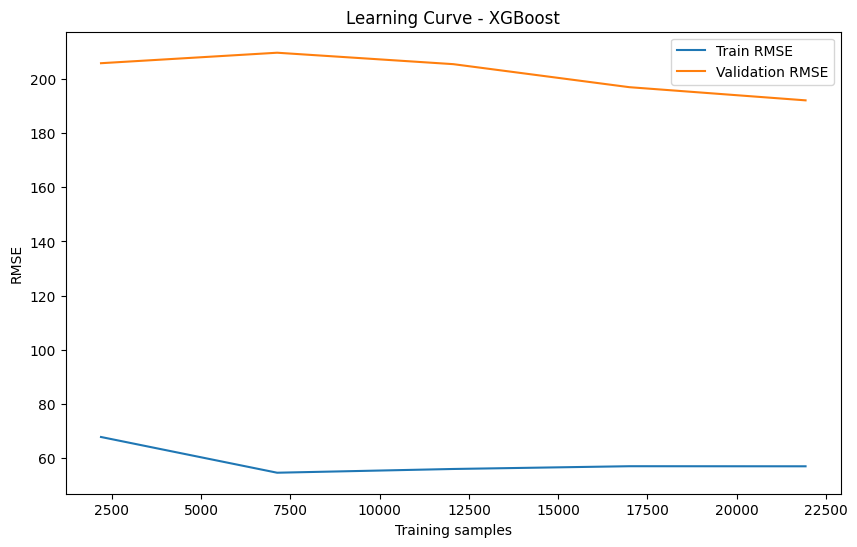

In [68]:
pred_train_xgb_target = model_xgb_target.predict(X_train_target)
pred_val_xgb_target = model_xgb_target.predict(X_val_target)
gap_xgb_target = evaluate_gap(y_train, pred_train_xgb_target, y_val, pred_val_xgb_target, "XGBoost")
addmet_xgb_target = evaluate_additional_metrics(y_val, pred_val_xgb_target, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_target.best_params,
    X_train_target,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target, X_train_target, y_train, "XGBoost")


In [69]:
perm_xgb_target = permutation_importance(model_xgb_target, X_val_target, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target.columns,
    'importance_mean': perm_xgb_target.importances_mean,
    'importance_std': perm_xgb_target.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target, f'{Output_directory}permutation_result_xgb_target.pkl')

print(feature_importances)

                         feature  importance_mean  importance_std
3  country_store_product_encoded         0.383131        0.001733
4            target_enc__country         0.116437        0.000947
6            target_enc__product         0.104402        0.000667
5              target_enc__store         0.068741        0.000710
7                      dayofweek         0.030681        0.000521
2        country_product_encoded         0.019093        0.000273
9                      dayofyear         0.015362        0.000261
8                           year         0.000000        0.000000
0          country_store_encoded        -0.009130        0.000161
1          store_product_encoded        -0.009734        0.000247


In [70]:
#XGBoost with only target encoding without second level interaction

X_train_target_wtSC = X_train.drop(['country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target_wtSC = X_val.drop(['country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()


X_test_target_wtSC = X_test.drop(['country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [71]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 150),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.60, 0.80),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.50, 0.80),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target_wtSC)):
        X_tr, X_va = X_train_target_wtSC.iloc[train_idx], X_train_target_wtSC.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target_wtSC = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target_wtSC.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target_wtSC.best_params}")

# saves the study
joblib.dump(study_xgb_target_wtSC, f'{Output_directory}study_xgb_target_wtSC.pkl')

#Load study 
#study_xgb_target_wtSC = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target_wtSC.pkl')

[I 2026-09-19 23:51:05,200] A new study created in memory with name: no-name-91e9b9be-5c7d-445b-b44b-f62f80738f68
[I 2026-09-19 23:51:20,295] Trial 0 finished with value: 177.47328651921765 and parameters: {'n_estimators': 750, 'learning_rate': 0.021936885140847334, 'max_depth': 2, 'min_child_weight': 140, 'gamma': 4.040443700223642, 'subsample': 0.6018394103233259, 'colsample_bytree': 0.525367885716508, 'colsample_bylevel': 0.6990505307324167, 'reg_alpha': 0.10235832435175114, 'reg_lambda': 38.86165206266039}. Best is trial 0 with value: 177.47328651921765.
[I 2026-09-19 23:51:31,967] Trial 1 finished with value: 147.02140100435656 and parameters: {'n_estimators': 684, 'learning_rate': 0.04277085190009591, 'max_depth': 3, 'min_child_weight': 72, 'gamma': 5.154413091020758, 'subsample': 0.64744981749936, 'colsample_bytree': 0.5813499245398169, 'colsample_bylevel': 0.7239474215354073, 'reg_alpha': 1.9918920492197516, 'reg_lambda': 117.68007747405215}. Best is trial 1 with value: 147.021

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 806, 'learning_rate': 0.05878501629122761, 'max_depth': 4, 'min_child_weight': 55, 'gamma': 1.189517590869516, 'subsample': 0.7512172569370935, 'colsample_bytree': 0.6381662759069795, 'colsample_bylevel': 0.7676434511086656, 'reg_alpha': 4.048730550316573, 'reg_lambda': 34.27234460022394}


['/kaggle/working/study_xgb_target_wtSC.pkl']

In [72]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target_wtSC) * 0.8)

df_train = X_train_target_wtSC.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target_wtSC.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target_wtSC = xgb.XGBRegressor(**study_xgb_target_wtSC.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target_wtSC.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target_wtSC, f'{Output_directory}model_xgb_target_wtSC.pkl')

#Load study 
#model_xgb_target_wtSC = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target_wtSC.pkl')

['/kaggle/working/model_xgb_target_wtSC.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 115.6401 | RMSE val: 192.9691
Gap: 77.3290 (66.87%)
--- XGBoost: Additional metrics ---
MAE: 109.2824 | MAPE: 1240298614000824320.00% | R²: 0.9096 | RMSLE: N/A (negative predictions)
Bias (mean error): -68.6651
Prediction std: 732.3051 | Real std: 641.8150
Within ±10%: 37.55%
Within ±15%: 50.91%
Within ±20%: 60.42%
Fold 1: 162.4606
Fold 2: 125.2835
Fold 3: 141.8623
Fold 4: 112.2037
Fold 5: 106.5497
CV mean: 129.6720
CV std: 20.4095


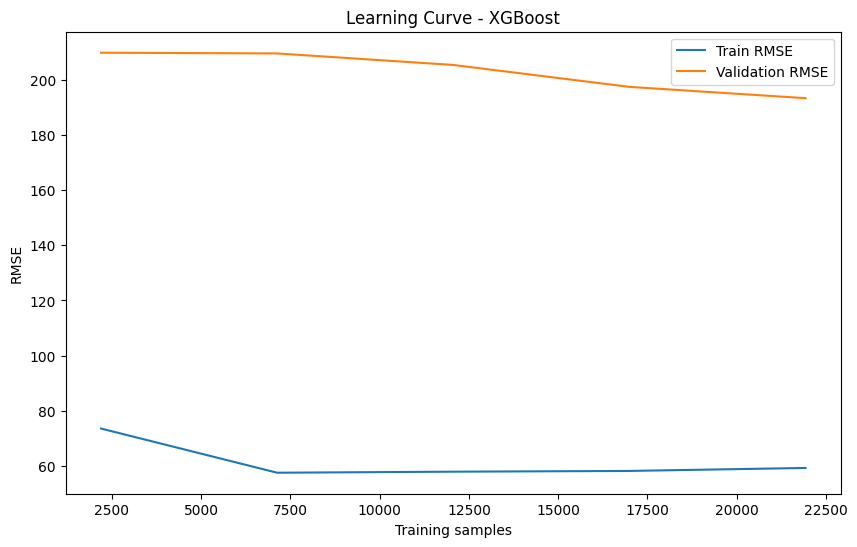

In [73]:
pred_train_xgb_target_wtSC = model_xgb_target_wtSC.predict(X_train_target_wtSC)
pred_val_xgb_target_wtSC = model_xgb_target_wtSC.predict(X_val_target_wtSC)
gap_xgb_target_wtSC = evaluate_gap(y_train, pred_train_xgb_target_wtSC, y_val, pred_val_xgb_target_wtSC, "XGBoost")
addmet_xgb_target_wtSC = evaluate_additional_metrics(y_val, pred_val_xgb_target_wtSC, "XGBoost")
cv_xgb_wtSC = cross_val_xgb(
    study_xgb_target_wtSC.best_params,
    X_train_target_wtSC,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target_wtSC, X_train_target_wtSC, y_train, "XGBoost")


In [74]:
perm_xgb_target_wtSC = permutation_importance(model_xgb_target_wtSC, X_val_target_wtSC, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target_wtSC= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target_wtSC.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target_wtSC.columns,
    'importance_mean': perm_xgb_target_wtSC.importances_mean,
    'importance_std': perm_xgb_target_wtSC.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target_wtSC, f'{Output_directory}permutation_result_xgb_target_wtSC.pkl')

print(feature_importances)

                         feature  importance_mean  importance_std
0  country_store_product_encoded         0.734136        0.002992
1            target_enc__country         0.135001        0.000778
3            target_enc__product         0.106661        0.000689
2              target_enc__store         0.051436        0.000795
4                      dayofweek         0.026478        0.000464
6                      dayofyear         0.008786        0.000187
5                           year         0.000000        0.000000


In [75]:
# XGBoost with only target encoding without first and second level interaction

X_train_target_wtFC = X_train.drop(['target_enc__store', 'target_enc__country', 'target_enc__product','country_store_encoded',
                                    'store_product_encoded', 'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target_wtFC = X_val.drop(['target_enc__store', 'target_enc__country', 'target_enc__product','country_store_encoded',
                                    'store_product_encoded', 'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_test_target_wtFC = X_test.drop(['target_enc__store', 'target_enc__country', 'target_enc__product','country_store_encoded',
                                    'store_product_encoded', 'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [76]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 150),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.60, 0.80),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.50, 0.80),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target_wtFC)):
        X_tr, X_va = X_train_target_wtFC.iloc[train_idx], X_train_target_wtFC.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target_wtFC = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target_wtFC.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target_wtFC.best_params}")

# saves the study
joblib.dump(study_xgb_target_wtFC, f'{Output_directory}study_xgb_target_wtFC.pkl')

#Load study 
#study_xgb_target_wtFC = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target_wtFC.pkl')

[I 2026-09-20 00:15:21,406] A new study created in memory with name: no-name-8f4f53be-00cd-42e7-ab3c-43dd5f8a7789
[I 2026-09-20 00:15:27,454] Trial 0 finished with value: 256.66446026009055 and parameters: {'n_estimators': 336, 'learning_rate': 0.03585507078145893, 'max_depth': 3, 'min_child_weight': 114, 'gamma': 5.322201753534139, 'subsample': 0.795170415892507, 'colsample_bytree': 0.6290750870752988, 'colsample_bylevel': 0.5968869418823738, 'reg_alpha': 3.893788781594571, 'reg_lambda': 46.390053626386845}. Best is trial 0 with value: 256.66446026009055.
[I 2026-09-20 00:15:38,093] Trial 1 finished with value: 260.0337255289039 and parameters: {'n_estimators': 607, 'learning_rate': 0.021800336778287976, 'max_depth': 2, 'min_child_weight': 147, 'gamma': 6.854568494872217, 'subsample': 0.7391948412187397, 'colsample_bytree': 0.6022382361035674, 'colsample_bylevel': 0.5519882960212538, 'reg_alpha': 0.20552946196390165, 'reg_lambda': 44.87800414421556}. Best is trial 0 with value: 256.66

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 949, 'learning_rate': 0.04923590768321795, 'max_depth': 3, 'min_child_weight': 78, 'gamma': 8.37082317918883, 'subsample': 0.7404947193957202, 'colsample_bytree': 0.6846876173380438, 'colsample_bylevel': 0.6890383138832348, 'reg_alpha': 1.5192129507311147, 'reg_lambda': 60.8859707653375}


['/kaggle/working/study_xgb_target_wtFC.pkl']

In [77]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target_wtFC) * 0.8)

df_train = X_train_target_wtFC.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target_wtFC.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target_wtFC = xgb.XGBRegressor(**study_xgb_target_wtFC.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target_wtFC.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target_wtFC, f'{Output_directory}model_xgb_target_wtFC.pkl')

#Load study 
#model_xgb_target_wtFC = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target_wtFC.pkl')

['/kaggle/working/model_xgb_target_wtFC.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 278.1431 | RMSE val: 193.3197
Gap: -84.8233 (-30.50%)
--- XGBoost: Additional metrics ---
MAE: 114.0463 | MAPE: 918184391619380608.00% | R²: 0.9093 | RMSLE: N/A (negative predictions)
Bias (mean error): -55.2744
Prediction std: 730.1221 | Real std: 641.8150
Within ±10%: 33.55%
Within ±15%: 46.82%
Within ±20%: 57.19%
Fold 1: 703.6625
Fold 2: 149.2065
Fold 3: 149.9767
Fold 4: 126.3027
Fold 5: 123.1425
CV mean: 250.4582
CV std: 226.8773


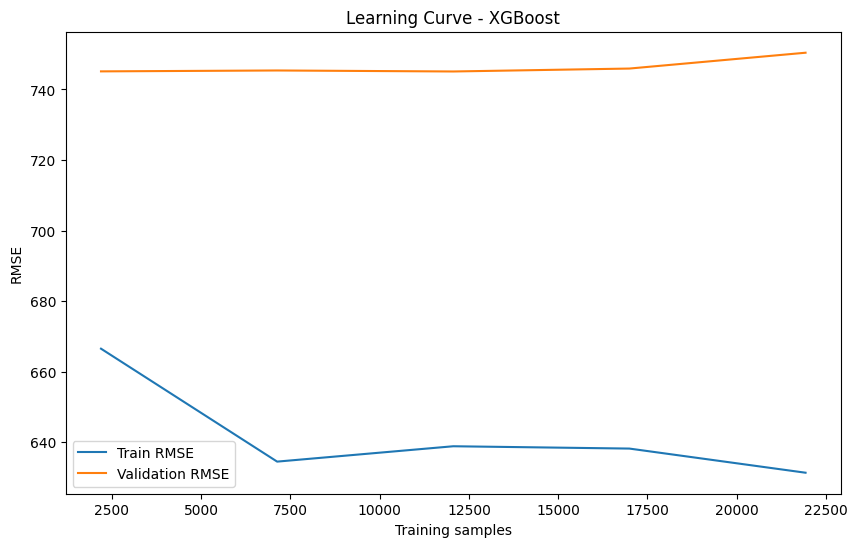

In [78]:
pred_train_xgb_target_wtFC = model_xgb_target_wtFC.predict(X_train_target_wtFC)
pred_val_xgb_target_wtFC = model_xgb_target_wtFC.predict(X_val_target_wtFC)
gap_xgb_target_wtFC = evaluate_gap(y_train, pred_train_xgb_target_wtFC, y_val, pred_val_xgb_target_wtFC, "XGBoost")
addmet_xgb_target_wtFC = evaluate_additional_metrics(y_val, pred_val_xgb_target_wtFC, "XGBoost")
cv_xgb_wtFC = cross_val_xgb(
    study_xgb_target_wtFC.best_params,
    X_train_target_wtFC,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target_wtFC, X_train_target_wtFC, y_train, "XGBoost")


In [79]:
perm_xgb_target_wtFC = permutation_importance(model_xgb_target_wtFC, X_val_target_wtFC, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target_wtFC= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target_wtFC.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target_wtFC.columns,
    'importance_mean': perm_xgb_target_wtFC.importances_mean,
    'importance_std': perm_xgb_target_wtFC.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target_wtFC, f'{Output_directory}permutation_result_xgb_target_wtFC.pkl')

print(feature_importances)

                         feature  importance_mean  importance_std
0  country_store_product_encoded         2.189734        0.009274
1                      dayofweek         0.025335        0.000332
3                      dayofyear         0.005266        0.000119
2                           year         0.000000        0.000000


In [80]:
#Onehot encoding dataframe
X_train_onehot = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()


X_val_onehot = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()

X_test_onehot = X_test.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()

In [81]:
# XGBoost with only onehot encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 150),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot)):
        X_tr, X_va = X_train_onehot.iloc[train_idx], X_train_onehot.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_onehot = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_onehot.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_onehot.best_params}")

# saves the study
joblib.dump(study_xgb_onehot, f'{Output_directory}study_xgb_onehot.pkl')

#Load study 
#study_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl')

[I 2026-09-20 00:24:27,202] A new study created in memory with name: no-name-91a20cb3-b0fa-42cc-9eac-8d3209465010
[I 2026-09-20 00:24:41,735] Trial 0 finished with value: 146.71274145679843 and parameters: {'n_estimators': 372, 'learning_rate': 0.053908490462518145, 'max_depth': 3, 'min_child_weight': 133, 'gamma': 2.089534764232496, 'subsample': 0.7791046456992401, 'colsample_bytree': 0.5973004196835408, 'colsample_bylevel': 0.5032512954440895, 'reg_alpha': 6.467909772210834, 'reg_lambda': 34.74784724062925}. Best is trial 0 with value: 146.71274145679843.
[I 2026-09-20 00:25:04,130] Trial 1 finished with value: 125.80699084565894 and parameters: {'n_estimators': 523, 'learning_rate': 0.05679691583380161, 'max_depth': 4, 'min_child_weight': 107, 'gamma': 4.283879164439553, 'subsample': 0.689689104395664, 'colsample_bytree': 0.5733026929245162, 'colsample_bylevel': 0.5985993636109748, 'reg_alpha': 2.2132828159895985, 'reg_lambda': 100.69513368580152}. Best is trial 1 with value: 125.80

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 980, 'learning_rate': 0.049047914503461014, 'max_depth': 4, 'min_child_weight': 92, 'gamma': 6.344009500006344, 'subsample': 0.6469374208986749, 'colsample_bytree': 0.6761501273267382, 'colsample_bylevel': 0.6836803838174708, 'reg_alpha': 0.5054870561228, 'reg_lambda': 53.74604201406044}


['/kaggle/working/study_xgb_onehot.pkl']

In [82]:
print(f"Trials executed: {len(study_xgb_onehot.trials)}")
print(f"Best trial: {study_xgb_onehot.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot.best_params}")

Trials executed: 112
Best trial: 51
Best RMSE: 121.2444
Best parameters: {'n_estimators': 980, 'learning_rate': 0.049047914503461014, 'max_depth': 4, 'min_child_weight': 92, 'gamma': 6.344009500006344, 'subsample': 0.6469374208986749, 'colsample_bytree': 0.6761501273267382, 'colsample_bylevel': 0.6836803838174708, 'reg_alpha': 0.5054870561228, 'reg_lambda': 53.74604201406044}


In [83]:
### Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_onehot) * 0.8)

df_train = X_train_onehot.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_onehot.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_onehot = xgb.XGBRegressor(**study_xgb_onehot.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_onehot.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_onehot, f'{Output_directory}model_xgb_onehot.pkl')

#Load study 
#model_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot .pkl')

['/kaggle/working/model_xgb_onehot.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 88.9652 | RMSE val: 178.4925
Gap: 89.5273 (100.63%)
--- XGBoost: Additional metrics ---
MAE: 101.4984 | MAPE: 981097874096034944.00% | R²: 0.9227 | RMSLE: N/A (negative predictions)
Bias (mean error): -54.0819
Prediction std: 718.1561 | Real std: 641.8150
Within ±10%: 40.39%
Within ±15%: 54.43%
Within ±20%: 63.48%
Fold 1: 161.0738
Fold 2: 124.3958
Fold 3: 111.8151
Fold 4: 99.5046
Fold 5: 109.4328
CV mean: 121.2444
CV std: 21.4353


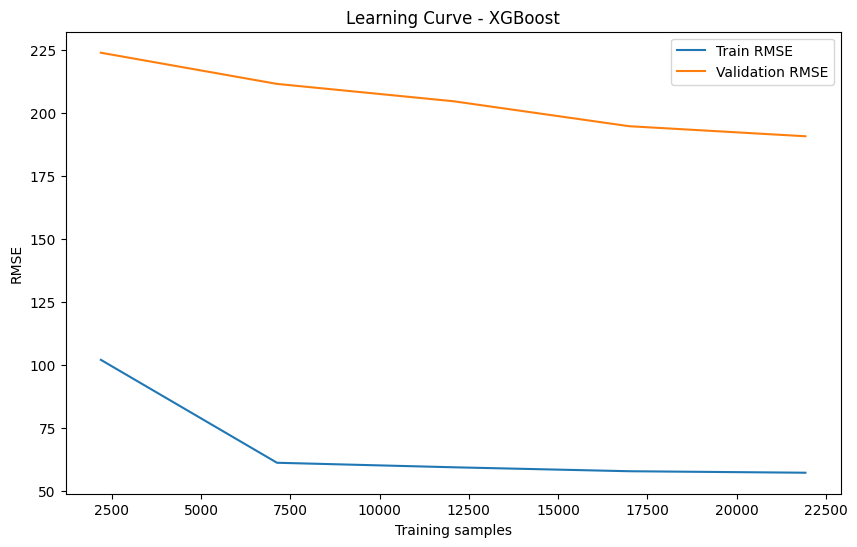

In [84]:
pred_train_xgb_onehot = model_xgb_onehot.predict(X_train_onehot)
pred_val_xgb_onehot = model_xgb_onehot.predict(X_val_onehot)
gap_xgb_onehot = evaluate_gap(y_train, pred_train_xgb_onehot, y_val, pred_val_xgb_onehot, "XGBoost")
addmet_xgb_onehot = evaluate_additional_metrics(y_val, pred_val_xgb_onehot, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_onehot.best_params,
    X_train_onehot,
    y_train,
    tscv)
plot_learning_curve(model_xgb_onehot, X_train_onehot, y_train, "XGBoost")


In [85]:
perm_xgb_onehot = permutation_importance(model_xgb_onehot, X_val_onehot, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot.columns,
    'importance_mean': perm_xgb_onehot.importances_mean,
    'importance_std': perm_xgb_onehot.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot, f'{Output_directory}permutation_result_xgb_onehot.pkl')

print(feature_importances)

                       feature  importance_mean  importance_std
7               country_Norway         0.425131        0.002349
6                country_Kenya         0.422162        0.002157
13              product_Kaggle         0.308463        0.001964
12   product_Holographic Goose         0.264645        0.001301
9      store_Discount Stickers         0.239655        0.001955
14        product_Kaggle Tiers         0.101590        0.000924
10  store_Premium Sticker Mart         0.045217        0.000887
5                country_Italy         0.028803        0.000219
0                    dayofweek         0.028153        0.000461
8            country_Singapore         0.017695        0.000087
2                    dayofyear         0.016711        0.000231
15            product_Kerneler         0.015211        0.000244
16  product_Kerneler Dark Mode         0.005251        0.000055
1                         year         0.000000        0.000000
3               country_Canada        -0

In [86]:
# XGBoost with onehot encoding and triple interaction of target encoding
X_train_onehot_tr = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded'], axis=1).copy()


X_val_onehot_tr = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded'], axis=1).copy()

X_test_onehot_tr = X_test.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded'], axis=1).copy()

In [87]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'min_child_weight': trial.suggest_int('min_child_weight', 50, 150),
        'gamma': trial.suggest_float('gamma', 1, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.80),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 0.75),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 30, 150.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot_tr)):
        X_tr, X_va = X_train_onehot_tr.iloc[train_idx], X_train_onehot_tr.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_onehot_tr = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_onehot_tr.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_onehot_tr.best_params}")

# saves the study
joblib.dump(study_xgb_onehot_tr, f'{Output_directory}study_xgb_onehot_tr.pkl')

#Load study 
#study_xgb_onehot_tr = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot_tr.pkl')

[I 2026-09-20 01:06:14,372] A new study created in memory with name: no-name-3331bd4a-6e8e-4c5d-a69d-5732bf9b5494
[I 2026-09-20 01:06:32,980] Trial 0 finished with value: 165.54253885961498 and parameters: {'n_estimators': 789, 'learning_rate': 0.036042338956199856, 'max_depth': 2, 'min_child_weight': 132, 'gamma': 4.838727585612752, 'subsample': 0.6325233878689782, 'colsample_bytree': 0.7277317961234606, 'colsample_bylevel': 0.7467611728769508, 'reg_alpha': 7.935966513082414, 'reg_lambda': 96.46670011418793}. Best is trial 0 with value: 165.54253885961498.
[I 2026-09-20 01:06:49,173] Trial 1 finished with value: 136.7557968435277 and parameters: {'n_estimators': 730, 'learning_rate': 0.031665229347396295, 'max_depth': 4, 'min_child_weight': 137, 'gamma': 1.1097334326431894, 'subsample': 0.6052733948994504, 'colsample_bytree': 0.5941158417195124, 'colsample_bylevel': 0.7431659992345498, 'reg_alpha': 9.430880863674352, 'reg_lambda': 38.21713704942251}. Best is trial 1 with value: 136.75

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 703, 'learning_rate': 0.05589784419862356, 'max_depth': 4, 'min_child_weight': 106, 'gamma': 7.607720336201456, 'subsample': 0.6329796166668308, 'colsample_bytree': 0.7470909353992562, 'colsample_bylevel': 0.606065767885498, 'reg_alpha': 1.279199144782184, 'reg_lambda': 40.35913962343281}


['/kaggle/working/study_xgb_onehot_tr.pkl']

In [88]:
print(f"Trials executed: {len(study_xgb_onehot_tr.trials)}")
print(f"Best trial: {study_xgb_onehot_tr.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot_tr.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot_tr.best_params}")

Trials executed: 104
Best trial: 43
Best RMSE: 126.9774
Best parameters: {'n_estimators': 703, 'learning_rate': 0.05589784419862356, 'max_depth': 4, 'min_child_weight': 106, 'gamma': 7.607720336201456, 'subsample': 0.6329796166668308, 'colsample_bytree': 0.7470909353992562, 'colsample_bylevel': 0.606065767885498, 'reg_alpha': 1.279199144782184, 'reg_lambda': 40.35913962343281}


In [89]:
### Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_onehot_tr) * 0.8)

df_train = X_train_onehot_tr.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_onehot_tr.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_onehot_tr = xgb.XGBRegressor(**study_xgb_onehot_tr.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_onehot_tr.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_onehot_tr, f'{Output_directory}model_xgb_onehot_tr.pkl')

#Load study 
#model_xgb_onehot_tr = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot_tr.pkl')

['/kaggle/working/model_xgb_onehot_tr.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 115.0479 | RMSE val: 197.3973
Gap: 82.3494 (71.58%)
--- XGBoost: Additional metrics ---
MAE: 111.9294 | MAPE: 1312234859798643200.00% | R²: 0.9054 | RMSLE: N/A (negative predictions)
Bias (mean error): -75.8033
Prediction std: 733.0803 | Real std: 641.8150
Within ±10%: 38.35%
Within ±15%: 52.12%
Within ±20%: 61.98%
Fold 1: 160.5479
Fold 2: 107.8156
Fold 3: 145.2223
Fold 4: 110.4319
Fold 5: 110.8694
CV mean: 126.9774
CV std: 21.7267


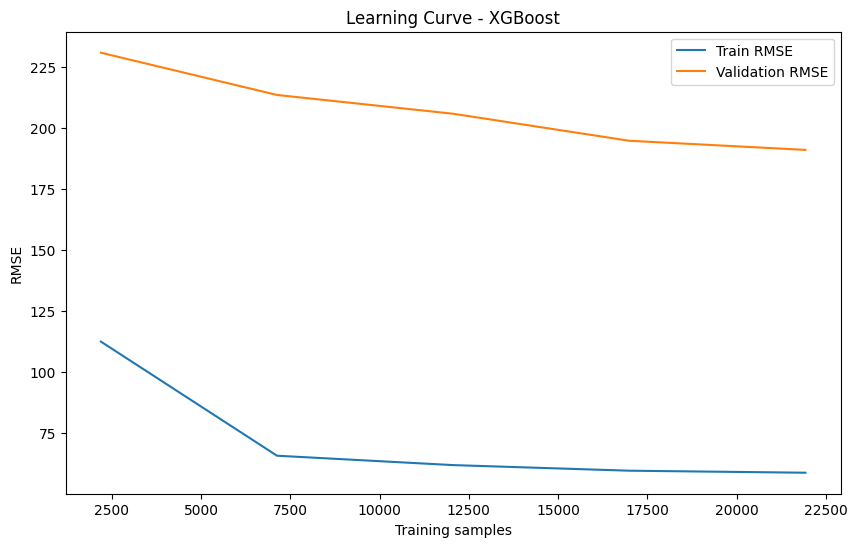

In [90]:
pred_train_xgb_onehot_tr = model_xgb_onehot_tr.predict(X_train_onehot_tr)
pred_val_xgb_onehot_tr = model_xgb_onehot_tr.predict(X_val_onehot_tr)
gap_xgb_onehot_tr = evaluate_gap(y_train, pred_train_xgb_onehot_tr, y_val, pred_val_xgb_onehot_tr, "XGBoost")
addmet_xgb_onehot_tr = evaluate_additional_metrics(y_val, pred_val_xgb_onehot_tr, "XGBoost")
cv_xgb_tr = cross_val_xgb(
    study_xgb_onehot_tr.best_params,
    X_train_onehot_tr,
    y_train,
    tscv)
plot_learning_curve(model_xgb_onehot_tr, X_train_onehot_tr, y_train, "XGBoost")


In [91]:
perm_xgb_onehot_tr = permutation_importance(model_xgb_onehot_tr, X_val_onehot_tr, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_onehot_tr = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot_tr.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot_tr.columns,
    'importance_mean': perm_xgb_onehot_tr.importances_mean,
    'importance_std': perm_xgb_onehot_tr.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot_tr, f'{Output_directory}permutation_result_xgb_onehot_tr.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
0   country_store_product_encoded         0.525536        0.001786
7                   country_Kenya         0.119411        0.000761
13      product_Holographic Goose         0.054102        0.000409
8                  country_Norway         0.040753        0.000799
14                 product_Kaggle         0.040394        0.000509
10        store_Discount Stickers         0.032151        0.000654
1                       dayofweek         0.027853        0.000456
3                       dayofyear         0.008722        0.000148
15           product_Kaggle Tiers         0.006785        0.000210
11     store_Premium Sticker Mart         0.006592        0.000375
6                   country_Italy         0.004119        0.000090
9               country_Singapore         0.003735        0.000027
16               product_Kerneler         0.003298        0.000136
17     product_Kerneler Dark Mode         0.001724        0.00

In [92]:
#target and onehot encoding
pred_val_xgb = model_xgb.predict(X_test)
joblib.dump(pred_val_xgb, f'{Output_directory}pred_val_xgb.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

#only target encoding
pred_val_xgb_target = model_xgb_target.predict(X_test_target)
joblib.dump(pred_val_xgb_target, f'{Output_directory}pred_val_xgb_target.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

# only target encoding without second level interaction
pred_val_xgb_target_wtSC = model_xgb_target_wtSC.predict(X_test_target_wtSC)
joblib.dump(pred_val_xgb_target_wtSC, f'{Output_directory}pred_val_xgb_target_wtSC.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

# only target encoding without first and second level interaction
pred_val_xgb_target_wtFC = model_xgb_target_wtFC.predict(X_test_target_wtFC)
joblib.dump(pred_val_xgb_target_wtFC, f'{Output_directory}pred_val_xgb_target_wtFC.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

# only onehot encoding
pred_val_xgb_onehot = model_xgb_onehot.predict(X_test_onehot)
joblib.dump(pred_val_xgb_onehot, f'{Output_directory}pred_val_xgb_onehot.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

# onehot encoding and triple interaction of target encoding
pred_val_xgb_onehot_tr = model_xgb_onehot_tr.predict(X_test_onehot_tr)
joblib.dump(pred_val_xgb_onehot_tr, f'{Output_directory}pred_val_xgb_onehot_tr.pkl')
#pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')


['/kaggle/working/pred_val_xgb_onehot_tr.pkl']

In [93]:
id_test = test_df['id'].values

submission_xgb = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb})
submission_xgb.to_csv(f'{Output_directory}submission_xgb.csv', index=False)

submission_xgb_target = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb_target})
submission_xgb_target.to_csv(f'{Output_directory}submission_xgb_target.csv', index=False)

submission_xgb_target_wtSC = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb_target_wtSC})
submission_xgb_target_wtSC.to_csv(f'{Output_directory}submission_xgb_target_wtSC.csv', index=False)

submission_xgb_target_wtFC = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb_target_wtFC})
submission_xgb_target_wtFC.to_csv(f'{Output_directory}submission_xgb_target_wtFC.csv', index=False)

submission_xgb_onehot = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb_onehot})
submission_xgb_onehot.to_csv(f'{Output_directory}submission_xgb_onehot.csv', index=False)

submission_xgb_onehot_tr = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb_onehot_tr})
submission_xgb_onehot_tr.to_csv(f'{Output_directory}submission_xgb_onehot_tr.csv', index=False)